# Pose Estimation para Bovinos com Animal-Pose

Este notebook implementa a atividade avaliativa a partir do **ANIMAL-POSE DATASET**, com foco na classe **cow**. O fluxo cobre:

1. analise exploratoria do dataset;
2. filtragem para bovinos;
3. processamento ilustrativo das imagens e das anotacoes de pose;
4. consolidacao dos resultados usados no `README.md`.


In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import pandas as pd
from IPython.display import Image, Markdown, display

REPO_ROOT = Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.bovine_pose_analysis import (
    generate_figures,
    generate_tables,
    load_dataset,
    save_filtered_cow_json,
)

DATA_DIR = REPO_ROOT / 'data'
RESULTS_DIR = REPO_ROOT / 'results'
FIGURES_DIR = RESULTS_DIR / 'figures'
TABLES_DIR = RESULTS_DIR / 'tables'
PROCESSED_DIR = RESULTS_DIR / 'processed'

DATASET = load_dataset(DATA_DIR / 'keypoints.json', DATA_DIR)
FIGURE_PATHS = generate_figures(DATASET, FIGURES_DIR)
TABLE_PATHS = generate_tables(DATASET, TABLES_DIR)
FILTERED_PATH = save_filtered_cow_json(DATASET, PROCESSED_DIR / 'cow_keypoints_local.json', local_only=True)

summary_df = pd.read_csv(TABLE_PATHS['dataset_summary'])
cow_summary_df = pd.read_csv(TABLE_PATHS['cow_summary'])
summary_df

,category_name,total_instances,unique_images,local_images,mean_bbox_area,mean_num_keypoints
0,dog,1771,1529,200,63771.42,20.0
1,cat,1466,1324,200,80339.13,20.0
2,sheep,1078,556,200,43625.67,20.0
3,horse,960,723,200,52556.78,20.0
4,cow,842,534,200,38440.85,20.0


## 1. Analise exploratoria do dataset

O dataset possui cinco categorias com anotacoes de pose: `dog`, `cat`, `sheep`, `horse` e `cow`. A partir do JSON oficial, calculamos a distribuicao de instancias, a quantidade de imagens unicas por classe e a cobertura de imagens realmente disponiveis no pacote local.


In [2]:
total_annotations = len(DATASET.annotations)
total_images_annotated = DATASET.annotations['image_name'].nunique()
cow_instances = len(DATASET.cow_all)
cow_unique_images = DATASET.cow_all['image_name'].nunique()
cow_local_images = DATASET.cow_local['image_name'].nunique()
cow_share = cow_instances / total_annotations
cow_local_coverage = cow_local_images / cow_unique_images

eda_metrics = pd.DataFrame(
    {
        'metrica': [
            'instancias_anotadas_total',
            'imagens_anotadas_total',
            'instancias_cow',
            'imagens_unicas_cow',
            'imagens_locais_cow',
            'proporcao_cow_no_dataset',
            'cobertura_local_cow',
        ],
        'valor': [
            total_annotations,
            total_images_annotated,
            cow_instances,
            cow_unique_images,
            cow_local_images,
            round(cow_share, 4),
            round(cow_local_coverage, 4),
        ],
    }
)
eda_metrics

,metrica,valor
0,instancias_anotadas_total,6117.0000
1,imagens_anotadas_total,4608.0000
2,instancias_cow,842.0000
3,imagens_unicas_cow,534.0000
4,imagens_locais_cow,200.0000
5,proporcao_cow_no_dataset,0.1376
6,cobertura_local_cow,0.3745


**Resumo por classe**

,category_name,total_instances,unique_images,local_images,mean_bbox_area,mean_num_keypoints
0,dog,1771,1529,200,63771.42,20.0
1,cat,1466,1324,200,80339.13,20.0
2,sheep,1078,556,200,43625.67,20.0
3,horse,960,723,200,52556.78,20.0
4,cow,842,534,200,38440.85,20.0


**Grafico 1: distribuicao de instancias por classe**

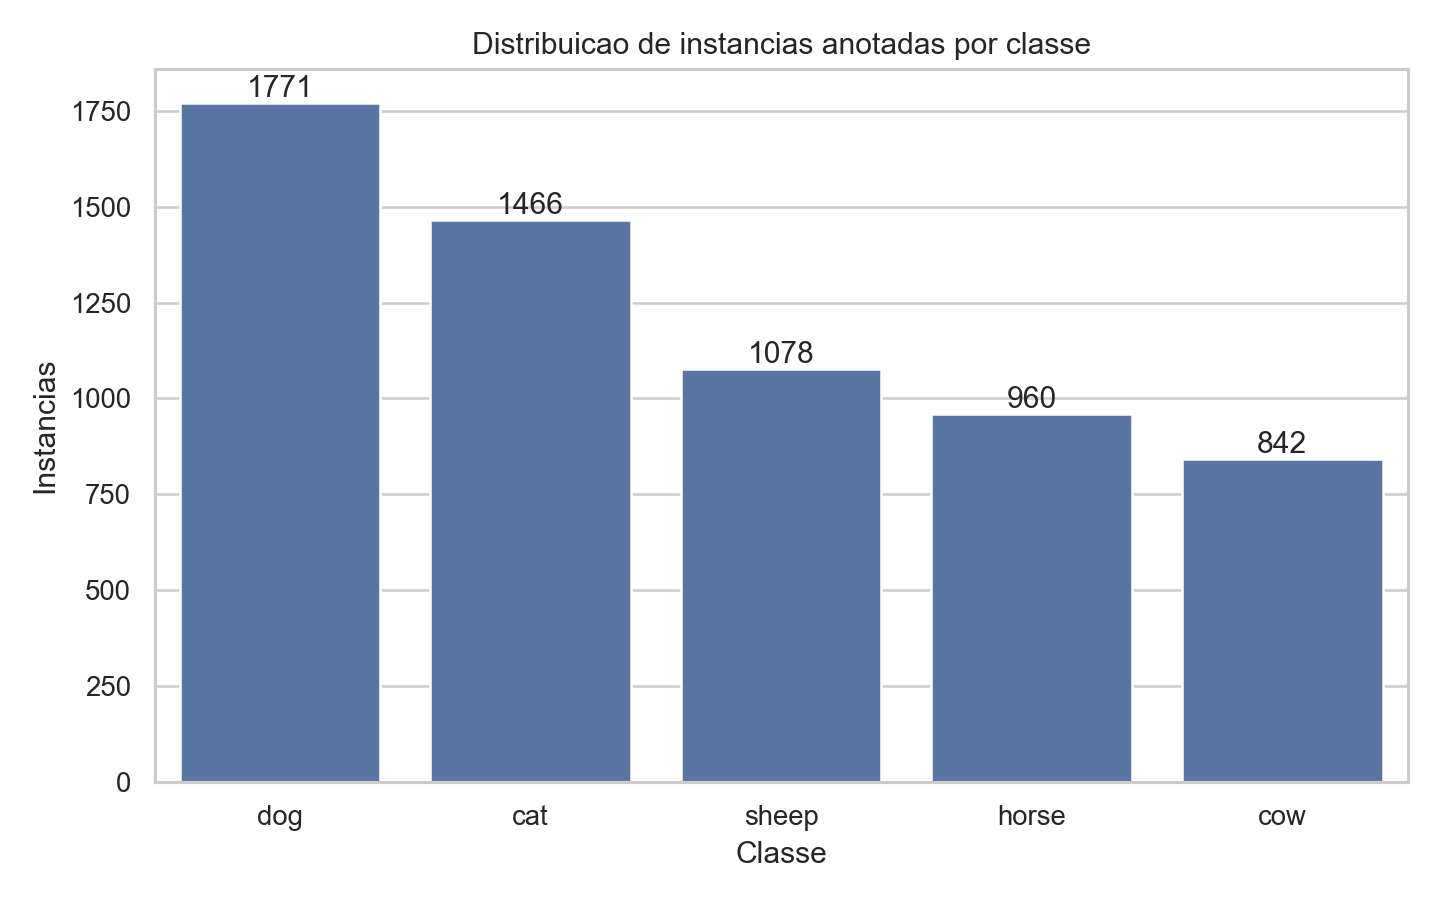

**Grafico 2: imagens anotadas vs. imagens locais**

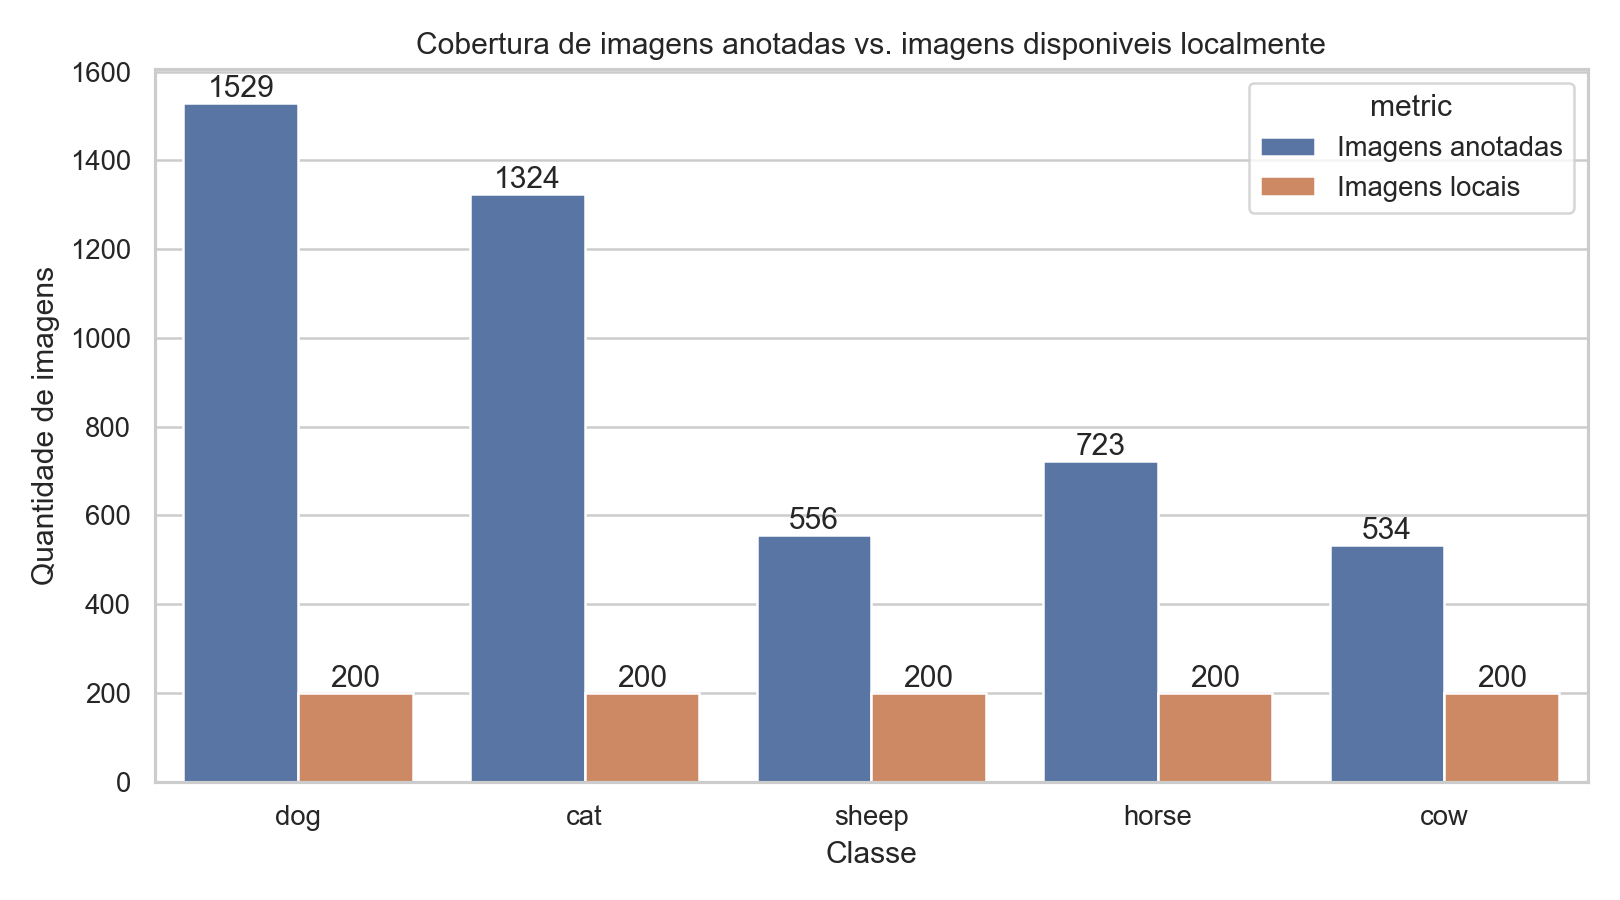

In [3]:
display(Markdown('**Resumo por classe**'))
display(summary_df)

display(Markdown('**Grafico 1: distribuicao de instancias por classe**'))
display(Image(filename=str(FIGURE_PATHS['instances_by_class'])))

display(Markdown('**Grafico 2: imagens anotadas vs. imagens locais**'))
display(Image(filename=str(FIGURE_PATHS['image_coverage'])))

**Leitura dos resultados da secao 1**

- O dataset possui **6117 instancias anotadas** em **4608 imagens unicas**.
- A classe **cow** representa **842 instancias**, equivalentes a **13,76%** do total anotado.
- Essas 842 instancias estao distribuidas em **534 imagens unicas** de bovinos.
- No pacote local baixado diretamente do Google Drive, apenas **200 imagens de bovinos** estao presentes, o que equivale a **37,45%** das imagens unicas de `cow` referenciadas no JSON.


## 2. Filtragem para bovinos e processamento de imagem

Nesta etapa, o pipeline filtra apenas anotacoes da categoria `cow` e salva um JSON reduzido em `results/processed/cow_keypoints_local.json`, contendo somente as imagens de bovinos disponiveis localmente.

Pipeline de processamento ilustrado:

1. localizar a anotacao `cow` no JSON;
2. resolver o caminho da imagem;
3. recortar a imagem usando a bounding box anotada;
4. redimensionar para `256 x 256` pixels;
5. aplicar ajuste leve de contraste e nitidez;
6. sobrepor bounding box, keypoints e esqueleto para inspecao visual.


In [4]:
import json

with FILTERED_PATH.open('r', encoding='utf-8') as handle:
    filtered_payload = json.load(handle)

processing_table = pd.DataFrame(
    {
        'artefato': ['json_filtrado_local', 'imagens_cow_locais', 'instancias_cow_locais'],
        'valor': [
            str(FILTERED_PATH.relative_to(REPO_ROOT)),
            DATASET.cow_local['image_name'].nunique(),
            len(filtered_payload['annotations']),
        ],
    }
)
processing_table

,artefato,valor
0,json_filtrado_local,results\processed\cow_keypoints_local.json
1,imagens_cow_locais,200
2,instancias_cow_locais,200


**Figura do pipeline de processamento**

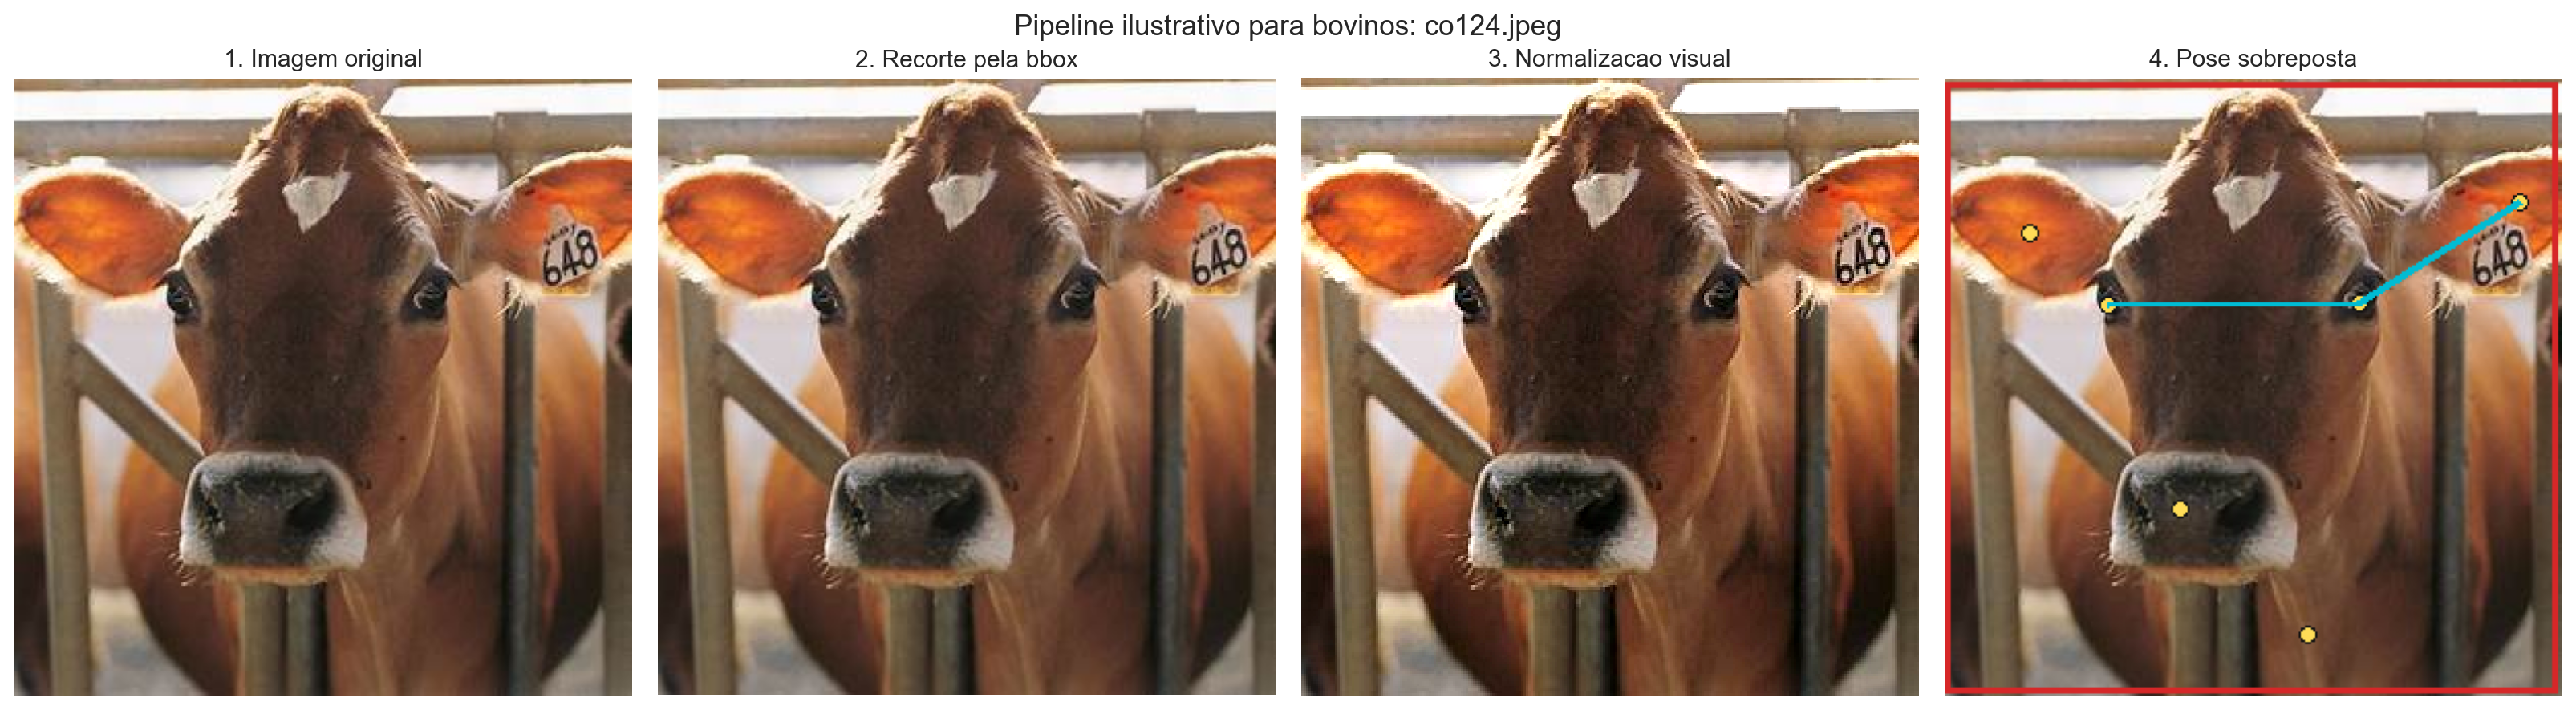

In [5]:
display(Markdown('**Figura do pipeline de processamento**'))
display(Image(filename=str(FIGURE_PATHS['processing_pipeline'])))

**Exemplo detalhado passo a passo**

O exemplo salvo na figura utiliza uma imagem de bovino com anotacao completa de pose. O comportamento esperado em cada etapa e:

- **Imagem original**: observamos o contexto completo da cena.
- **Recorte pela bbox**: removemos parte do fundo para concentrar a analise no animal.
- **Normalizacao visual**: padronizamos o tamanho da entrada e reforcamos levemente contraste/nitidez para inspe??o.
- **Pose sobreposta**: verificamos se os 20 keypoints e as conexoes do esqueleto acompanham corretamente a anatomia do bovino.


## 3. Resultados finais do processamento

Aqui resumimos os principais resultados obtidos a partir da classe `cow`, incluindo estatisticas do subconjunto, distribuicao das bounding boxes e a pose media normalizada.


**Tabela de resumo de bovinos**

,metric,value
0,instancias_anotadas_cow,842.0000
1,imagens_unicas_cow,534.0000
2,imagens_locais_cow,200.0000
3,proporcao_cow_no_dataset,0.1376
4,media_area_bbox_cow,38440.8500
5,media_keypoints_visiveis_cow,20.0000


**Estatisticas das bounding boxes locais de bovinos**

,bbox_width,bbox_height,bbox_area
count,200.00,200.00,200.00
mean,242.74,176.53,42993.88
std,42.20,35.01,11631.38
min,84.00,106.00,8904.00
25%,218.00,154.00,35163.00
50%,254.00,174.00,43782.00
75%,276.00,194.00,50796.00
max,297.00,296.00,87912.00


**Grafico 3: pose media normalizada**

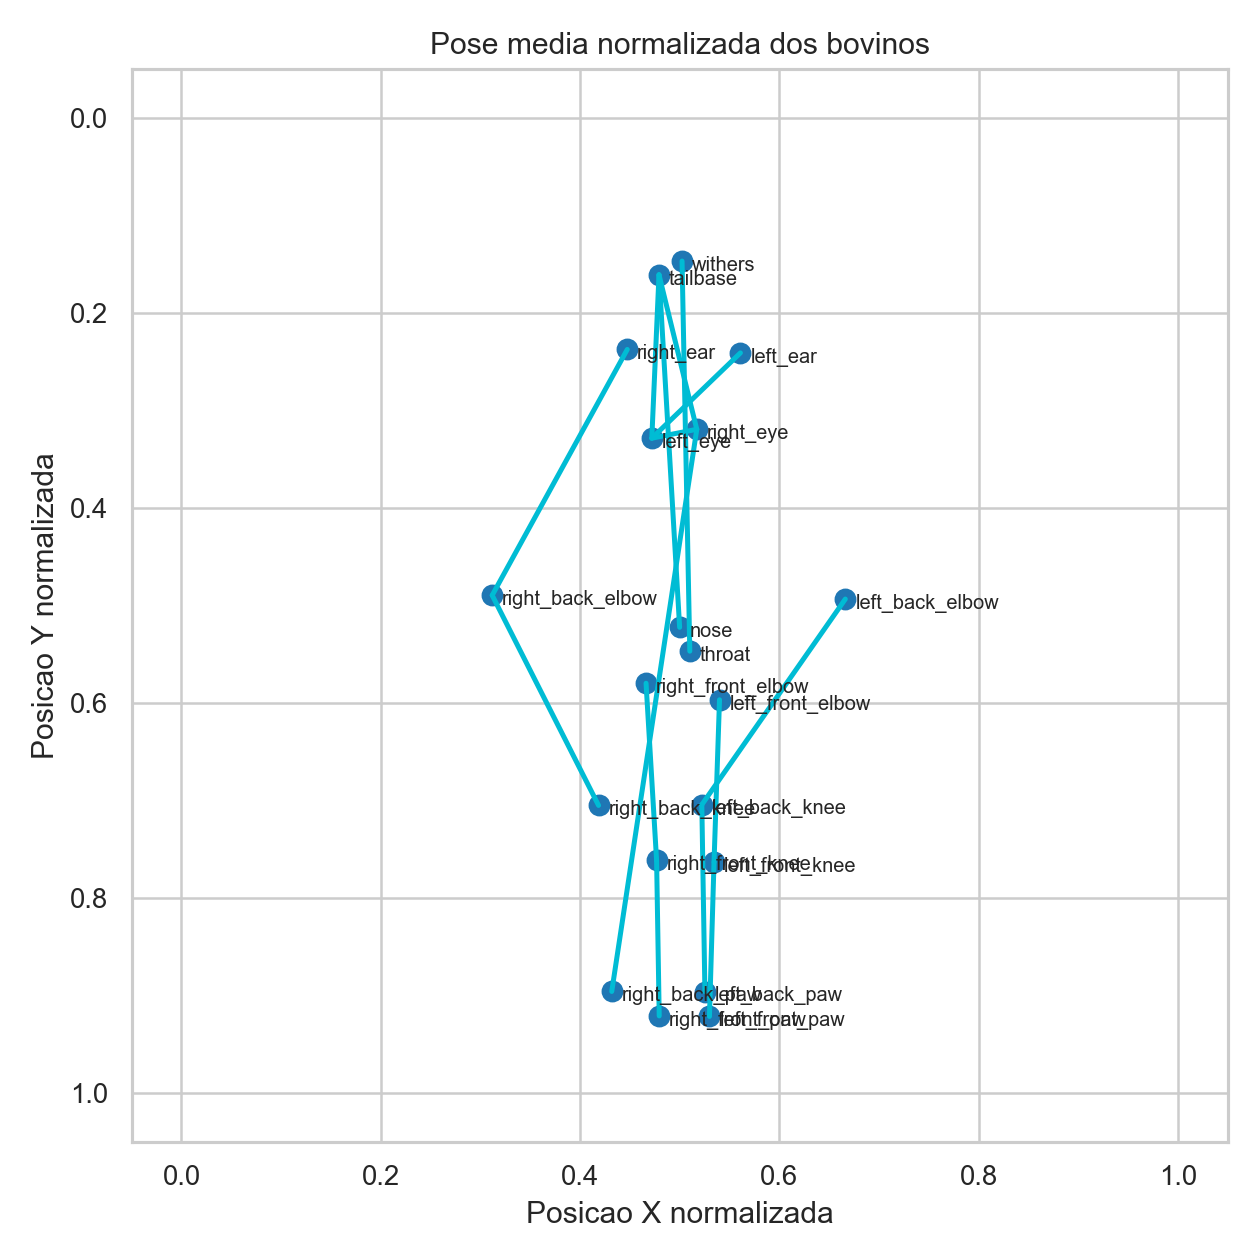

**Grafico 4: distribuicao da area das bounding boxes**

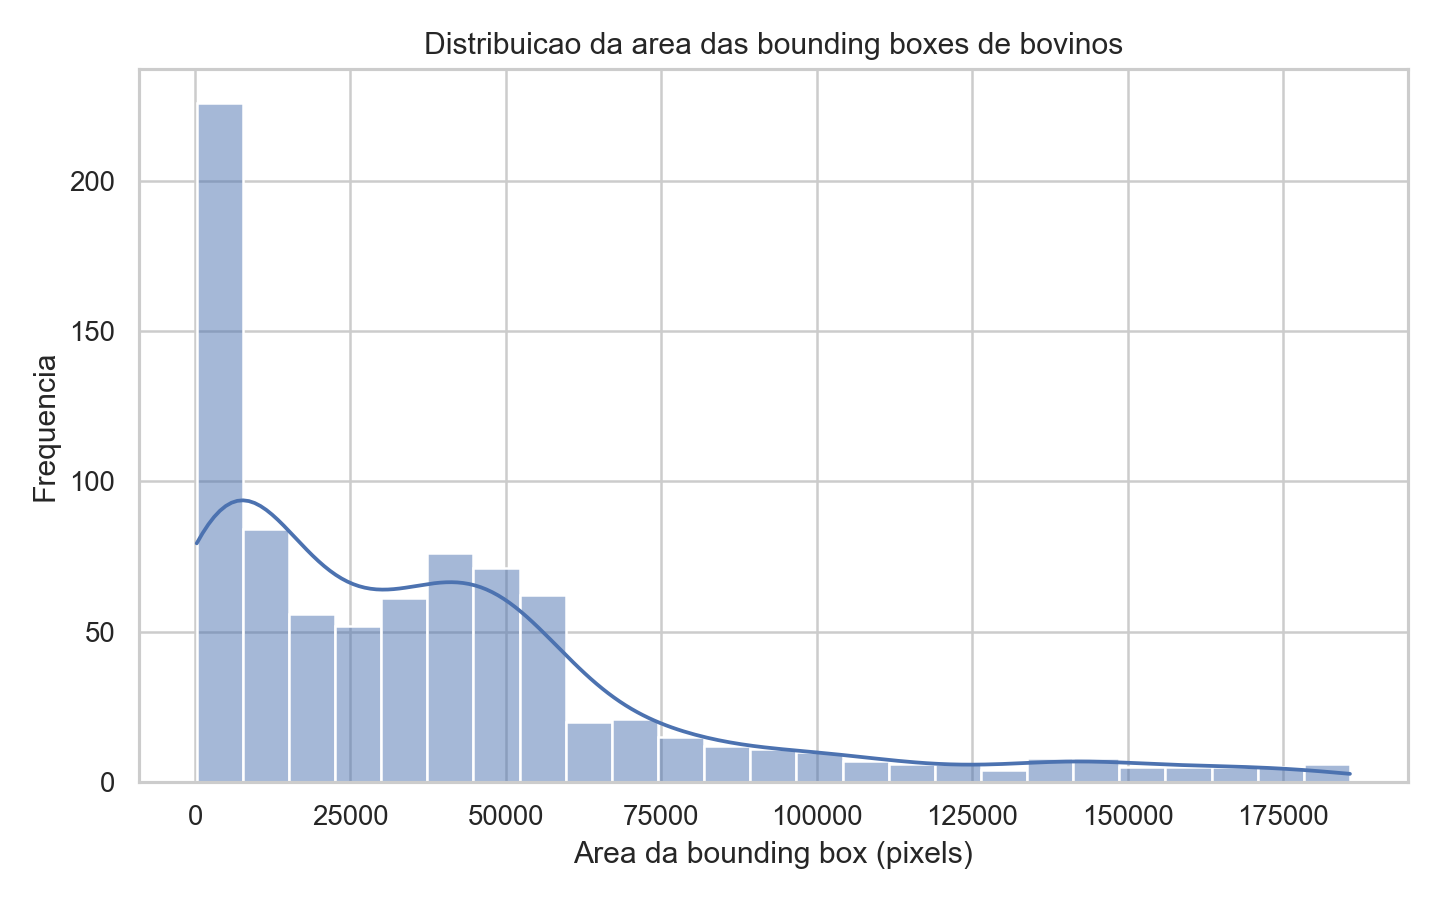

In [6]:
display(Markdown('**Tabela de resumo de bovinos**'))
display(cow_summary_df)

local_stats = DATASET.cow_local[['bbox_width', 'bbox_height', 'bbox_area']].describe().round(2)
display(Markdown('**Estatisticas das bounding boxes locais de bovinos**'))
display(local_stats)

display(Markdown('**Grafico 3: pose media normalizada**'))
display(Image(filename=str(FIGURE_PATHS['cow_keypoints'])))

display(Markdown('**Grafico 4: distribuicao da area das bounding boxes**'))
display(Image(filename=str(FIGURE_PATHS['cow_bbox_area'])))

**Leitura dos resultados da secao 3**

- O subconjunto completo de bovinos possui **842 instancias**.
- O subconjunto reproduzivel localmente possui **200 imagens** e **200 instancias** de bovinos.
- A area media das bounding boxes de bovinos no dataset completo e de aproximadamente **38.440,85 pixels**.
- A pose media normalizada mostra uma configuracao coerente com a anatomia esperada, o que indica boa consistencia geometrica das anotacoes de keypoints.


## 4. Observacoes para o README

O `README.md` do reposit?rio deve registrar:

- os graficos e tabelas produzidos em `results/`;
- a contagem de imagens de bovinos no dataset;
- a descricao do pipeline de filtragem e processamento;
- as conclusoes, limitacoes e trabalhos futuros.

Limitacao importante identificada durante a execucao: o pacote do Google Drive baixado localmente fornece **200 imagens por classe** na pasta `animalpose_image_part2`, enquanto o `keypoints.json` referencia um conjunto mais amplo de imagens do PASCAL VOC e de outras fontes. Para processar visualmente todas as **534 imagens unicas de bovinos**, seria necessario complementar o download dessas imagens externas.
